N-Queens


In [18]:
#nAttacks is how many pairs of ueens are attacking one another.
import random
import heapq

# Min-Heap => best solutions
# Max_heap => worst sol
class Heap:

  # constructor
  def __init__(self, Maximum_Size, New_Property):
    self.nHeap = 0                    # currently our size of heap = 0
    self.value = [0] * (Maximum_Size+1)  # value, index, pos everything
    self.index = [0] * (Maximum_Size+1)
    self.pos   = [0] * (Maximum_Size+1)
    self.Property = New_Property

  def Swap(self, u, v):
    # swapping elements in heaps. u and v
    self.value[u], self.value[v] = self.value[v], self.value[u]
    self.index[u], self.index[v] = self.index[v], self.index[u]
    self.pos[self.index[u]], self.pos[self.index[v]] = u, v

  def Up(self, node):
    # we are trying to obtain min_heap so we chek if child < parents if yes parent goes down child goes up
    # small values up. Focus on that
    while node > 1:
      parent = int(node / 2)
      if self.value[node] < self.value[parent]:
        self.Swap(parent, node)
        node = parent
      else:
        break

  def Down(self, node):
    # if node is greater than child move down. Nodes go downwards towards leafs
    while 2 * node <= self.nHeap:
        child = 2 * node
        if (child < self.nHeap) and (self.value[child + 1] < self.value[child]):
            child += 1
        if self.value[child] < self.value[node]:
            self.Swap(node, child)
            node = child
        else:
            break

  #The problem here is we want to use the same functions UP and DOWN to generate min and max heap .
  # But UP always generates min heap so we negate and obtain Max heap from it as result.
  def Push(self, New_Value, New_Index):
    # we push (nAttacks, i)
    # push new ele add it to the heap.
    # Push up and store in correct position
    self.nHeap += 1              # total elem increas
    if self.Property:           # Prop = true -> min
      self.value[self.nHeap] = New_Value   # firectly add the value
    else:
      self.value[self.nHeap] = -New_Value  # for max heap add negative value [ -8, -3, -2, 0] 8 is largest

    self.index[self.nHeap] = New_Index;
    self.pos[New_Index] = self.nHeap;
    self.Up(self.nHeap);

  def Pop(self, node):
    # remove element. adjust heap
    self.value[node] = self.value[self.nHeap]
    self.index[node] = self.index[self.nHeap]
    self.pos[self.index[node]] = node
    self.nHeap -= 1
    self.Up(node)
    self.Down(node)

  def Find_First_Best(self):
    # fetch the smallest element from heap
    return self.index[1]

  def Find_Second_Best(self):
    # For second best we are comparing both the children. left and the right child to fetch second smallest one
    if self.nHeap < 2:
      return self.index[1]
    if self.nHeap == 2:
      return self.index[2]
    if self.value[2] < self.value[3]:
      return self.index[2]
    return self.index[3]

class N_queens() :

        # constructor
        def __init__(self):

          self.Population = 10000          # 10000
          self.Max_nGenerations = 100000000  # 100000000
          self.nSwaps = 6
          self.generator = random.Random()
          self.TextName = "Solution"
          self.ImageName = "Solution.png"
          self.N = None
          self.Citizen = []
          self.result = []
          self.Heap_Min = []
          self.Heap_Max = []
          self.found = False



        # This function is used to return random column positions of queen
        def Random_Int(self, n):
          return self.generator.randint(0, n-1)


        class aCitizen:

            # aCitizen constructor to initialise every variable of this object
            def __init__(self, n, N_queens):
              # print("Reached init")
              self.N = n                       # number of rows and cols. what size the chessboard will be n*n
              self.Position_In_Row = [0] * n   # all of the queens positions index = row and value = col
              self.N_queens = N_queens
              self.Col = [0] * n               # number of queens that are existing in specific column
              self.Diagonal_Sum = [0] * (2*n)   # eg. (0,0) ; (0,1)(1,0); (0,2)(1,1)(2,0) ; (0,3)(1,2)(2,1)(3,0). Diagonal_Sum gives us forward diagonals. diagonals facing upwards.
              self.Diagonal_Difference = [0] * (2*n) # (0,3);(0,2),(1,3); (0,1)(1,2)(2,3) ; (0,0)(1,1)(2,2)(3,3); (1,0)(2,1)(3,2); (2,0)(3,1); (3,0). Diagonal Diff is backward diagonals.

            # reset to calculate for next generation
            # in reset function we reset it because we have to calculate every queen position after mutation wen we reach the next generation.
            # So before recalculating everythign again we RESET and initialise with 0
            def Reset(self):
              # nAttacks is how many pairs of ueens are attacking one another.
              self.nAttacks = 0
              N = self.N
              for i in range(0, N):
                self.Col[i] = 0
              for i in range(0, 2*N):
                self.Diagonal_Sum[i] = 0
                self.Diagonal_Difference[i] = 0
              # print(self.Col, self.Diagonal_Sum, self.Diagonal_Difference)

            # no of attacks = fitness
            def Recalculate_nAttacks(self):

              self.Reset()
              for i in range(0, self.N):

                j = self.Position_In_Row[i]   # j will have queen's column number.
                # inorder to find if there are any other queen can attack the current position
                self.nAttacks += self.Col[j] + self.Diagonal_Sum[i + j] + self.Diagonal_Difference[i - j + self.N]

                # shifting our queens position by 1 and again calculate nAttacks value. This will happen N times
                self.Col[j] += 1
                self.Diagonal_Sum[i+j] += 1
                self.Diagonal_Difference[i-j+self.N] += 1

            def Reduce(self, row, col1, col2):
              # trying to reduce the count of attacks happening right now for current position
              # we are doing this specific thing by changing our queens position
              delta1 = (self.Col[col1] - 1) + (self.Diagonal_Sum[row + col1] - 1) + (self.Diagonal_Difference[row - col1 + self.N] - 1)
              delta2 = self.Col[col2] + self.Diagonal_Sum[row + col2] + self.Diagonal_Difference[row - col2 + self.N]
              return delta1 - delta2


            def Assign(self, another):
              # assign self to another variable because we want to keep a track of the best sol.
              # Initial = worst then we will keep updating that solution
              self.N = another.N
              for i in range(0, self.N):
                self.Position_In_Row[i] = another.Position_In_Row[i]
              self.Recalculate_nAttacks()  # referring to current instance

            def Randomize(self):
              for i in range(0, self.N):
                # generate queens positions randomly using random_int method
                self.Position_In_Row[i] = self.N_queens.Random_Int(self.N)
              # now calling recalculate to check if the queens are under attack
              self.Recalculate_nAttacks()


            def Move(self, row, col1, col2):
              # move the queen to a different position by subtracting
              self.Col[col1] -= 1
              self.Diagonal_Sum[row + col1] -= 1
              self.Diagonal_Difference[row - col1 + self.N] -= 1

              self.Col[col2] += 1
              self.Diagonal_Sum[row + col2] += 1
              self.Diagonal_Difference[row - col2 + self.N] += 1

              self.Position_In_Row[row] = col2

            def Local_Optimization(self) :
              # move queen left, right to a position where attacks are reduced the most.
              # and there is no other improveement
              while True:
                  stop = True

                  for i in range(0, self.N):
                      while True:
                        # if we I move the queen attacks are decreased by 0. = Max_Reduce
                          Max_Reduce = 0
                          next = 0
                          # j will have queens position
                          j = self.Position_In_Row[i]

                          if j > 0:
                              # current position is not the leftmost position
                              if Max_Reduce < self.Reduce(i, j, j - 1):
                                  # if queen moves from this position to left check how many attacks are possible and how many decreased
                                  Max_Reduce = self.Reduce(i, j, j - 1)
                                  next = -1

                          if j < (self.N - 1):          # pos is not the last col
                              # if we got a conflict in first col (first row (0,0) and second row (0,1)) then Reduce(0,0,1) => Move from (0,0) to (0,1)
                              # we are moving right
                              if Max_Reduce < self.Reduce(i, j, j + 1):
                                  Max_Reduce = self.Reduce(i, j, j + 1)   # (2,3,2) move from 3 to 2col.
                                  next = 1

                          # execute if there is a new move of the queen that can reduce clashes/attacs
                          if Max_Reduce > 0:
                              # if good move is found update the no of attacks
                              stop = False
                              self.nAttacks -= Max_Reduce  # if attacks are lesser. nAttacks if = 6 , Max_Reduce = 3 then now we have = 3attacks
                               #(attacks reduced by 3) bcz we shifted
                              self.Move(i, j, j + next)   # move
                              continue        # check for the same queen position if attacks can be further reduced
                          break
                  if stop:
                      break;

            # mutation and crossover

            def Mutation(self):
              # print("Mutation Started")
              for i in range(0, self.N_queens.nSwaps):
                # we generate 2 random positions to swap called u and v
                u = self.N_queens.Random_Int(self.N)
                v = self.N_queens.Random_Int(self.N)

                temp = self.Position_In_Row[u]
                self.Position_In_Row[u] = self.Position_In_Row[v]
                self.Position_In_Row[v] = temp


            def Half_Father_Half_Mother_Crossover(self, father, mother):
              # print("Half_Father_Half_Mother_Crossover started")
              # 1st half from father 2nd half from mother  = child
              # In chessboard scenario this is like if we have 8 queens then 4 positions from mother and 4 from father
              for i in range(0, int(self.N/2)):
                self.Position_In_Row[i] = father.Position_In_Row[i]

              for i in range(int(self.N/2), self.N):
                self.Position_In_Row[i] = mother.Position_In_Row[i]

              self.Mutation()
              self.Recalculate_nAttacks()
              self.Local_Optimization()

            def Random_Crossover(self, father, mother):
              for i in range(0, self.N):
                j = self.N_queens.Random_Int(2)
                if j == 0:
                  self.Position_In_Row[i] = father.Position_In_Row[i]
                else:
                  self.Position_In_Row[i] = mother.Position_In_Row[i];

              self.Recalculate_nAttacks()
              self.Local_Optimization()

        # outside Citizen class
        def Input(self):
          while True:
            self.N = int(input("Size of the chessboard: "))
            if self.N > 1:
              print("\n")
              print("**Hyperparameters**")
              print("Size of Population = ",self.Population)
              print("Max-Generations = ", self.Max_nGenerations)
              print("Number of swaps = ", self.nSwaps)
              print("Size of chessboard = ", self.N)
              break
            if self.N < 1:
              print("The table is invalid")

        def Init(self):
          # we have an array that allows space for 10,000 solutions bcz pop = 10,000
          # Population has 10,000 possible solutions to N-Queen. [citizen0, citizen1...]
          # citizen = one solution i.e one full board solution of N-Queen

          self.Citizen = [None] * self.Population
          print("Reached Init")

          for i in range(0, self.Population):

            # My Init is outside the aCitizen class. Create aCitizen class object and store it in self.Citizen[i]
            # Up next = aCitizen init
            self.Citizen[i] = self.aCitizen(self.N, self)
            self.Citizen[i].Randomize()
            self.Citizen[i].Local_Optimization()

            # print("Citizen N = ", self.Citizen[i].N, " Positions = ", self.Citizen[i].Position_In_Row ,
            #       "No of attacks = ", self.Citizen[i].nAttacks)

          # It is a complete Complete Binary Tree. The value of the root node must be the smallest among all its descendant nodes and
          # same thing must be done for its left and right sub-tree also.
          self.Heap_Min = Heap(self.Population, True)    # Min heap to find solutions
          self.Heap_Max = Heap(self.Population, False)

          for i in range(0, self.Population):
            self.Heap_Min.Push(self.Citizen[i].nAttacks, i)
            self.Heap_Max.Push(-self.Citizen[i].nAttacks, i)    # In max we must have the maximum element first so
          # print("Population = ",self.Citizen)

        # Hre we are finding the second smallest which wil be one of the members or children of the parent node which is the first smallest of the heap
        # Second best could be either left child or right child so we need to compare both and extract
        def Find_Second_Best(self):
          i = 0
          leftChld = 2 *i + 1
          rightChld = 2 * i + 2   # even = right

          if len(self.Heap_Min) == 2:
            # we have to return Heap_Min[left]
            return self.Heap_Min[leftChld]

          if self.Heap_Min[leftChld] < self.Heap_Min[rightChld]:
            return self.Heap_Min[rightChld]
          else:
            return self.Heap_Min[rightChld]

        def Update_Generation1(self,New_Citizen):
          if self.Heap_Max.nHeap == 0:
            return
          Max_Index = self.Heap_Max.Find_First_Best()
          if New_Citizen.nAttacks < self.Citizen[Max_Index].nAttacks:
            self.Heap_Min.Pop(self.Heap_Min.pos[Max_Index]);
            self.Heap_Max.Pop(self.Heap_Max.pos[Max_Index]);

            self.Citizen[Max_Index].Assign(New_Citizen);

            self.Heap_Min.Push(self.Citizen[Max_Index].nAttacks, Max_Index);
            self.Heap_Max.Push(self.Citizen[Max_Index].nAttacks, Max_Index);


        def Update_Generation(self, parent1, parent2):
          # create child object
          child = self.aCitizen(self.N, self)
          child.Half_Father_Half_Mother_Crossover(self.Citizen[parent1], self.Citizen[parent2])
          self.Update_Generation1(child)

          child.Half_Father_Half_Mother_Crossover(self.Citizen[parent2], self.Citizen[parent1]);
          self.Update_Generation1(child);

          child.Random_Crossover(self.Citizen[parent1], self.Citizen[parent2]);
          self.Update_Generation1(child);


        def Genetic_Algorithm(self):
          nGenerations = 0
          self.aCitizen.result = self.aCitizen(self.N, self)
          while(True):
            nGenerations += 1
            print("Generation = ", nGenerations)
            # returns citizen with fewest attacks = root of minheap. This
            index1 = self.Heap_Min.Find_First_Best()
            print("Minimum of attacking (Fitness Score): ", self.Citizen[index1].nAttacks)
            if self.Citizen[index1].nAttacks == 0:
              self.found = True
              self.aCitizen.result = self.Citizen[index1]
              break

            index2 = self.Heap_Min.Find_Second_Best()
            self.Update_Generation(index1, index2)
            while True:
                index1 = self.Random_Int(self.Population)
                index2 = self.Random_Int(self.Population)
                if index1 != index2:
                    break

            self.Update_Generation(index1, index2)

            index1 = self.Heap_Min.Find_First_Best()
            index2 = self.Heap_Max.Find_Second_Best()
            self.Update_Generation(index1, index2)

            if nGenerations == self.Max_nGenerations:
                break


          self.aCitizen.result = self.Citizen[self.Heap_Min.Find_First_Best()]

        def Write_Output(self, FileName):
          with open(FileName, 'w') as writer:
            writer.write(f"{self.N}\n")
            for i in range(self.N):
                print(f"[{i}, {self.aCitizen.result.Position_In_Row[i]}]")
                writer.write(f"{i} {self.aCitizen.result.Position_In_Row[i]}\n")
            writer.close()

        def main(self):
          self.Input()
          self.Init()
          self.Genetic_Algorithm()
          if not self.found:
            print("\nThe evolutionary algorithm cannot find a solution.")
            print("The most optimal solution is:")
          else:
            print("\nFound successfully a solution:")

          self.Write_Output(self.TextName)
          # self.Visualization.Make_Image(self.ImageName, self.N, self.result.Position_In_Row)



if __name__ == "__main__":
    # Created object of N_queens class. This wll call init constructor
    obj = N_queens()
    obj.main()

Size of the chessboard: 8


**Hyperparameters**
Size of Population =  100000
Max-Generations =  100000000
Number of swaps =  6
Size of chessboard =  8
Reached Init
Generation =  1
Minimum of attacking (Fitness Score):  0

Found successfully a solution:
[0, 2]
[1, 5]
[2, 7]
[3, 0]
[4, 3]
[5, 6]
[6, 4]
[7, 1]


Travelling SalesMan Problem


Travelling SalesMan Problem Small N

 ** Hyperparameters Used ** 
population size:  500
cities :  8
generations:  20
Select Percent:  10
Mutation Swaps:  3
Cities =  [[100, 29], [35, 99], [3, 71], [26, 10], [53, 78], [32, 28], [71, 37], [64, 18]] 

Generation 0:  Best Distance Obtained = 298.08
Generation 1:  Best Distance Obtained = 292.35
Generation 2:  Best Distance Obtained = 292.35
Generation 3:  Best Distance Obtained = 292.35
Generation 4:  Best Distance Obtained = 292.35
Generation 5:  Best Distance Obtained = 292.35
Generation 6:  Best Distance Obtained = 292.35
Generation 7:  Best Distance Obtained = 292.35
Generation 8:  Best Distance Obtained = 292.35
Generation 9:  Best Distance Obtained = 292.35
Generation 10:  Best Distance Obtained = 292.35
Generation 11:  Best Distance Obtained = 292.35
Generation 12:  Best Distance Obtained = 292.35
Generation 13:  Best Distance Obtained = 292.35
Generation 14:  Best Distance Obtained = 292.35
Generation 15:  Best Distance Obtained = 292.35
Generation 16:  Best Distance 

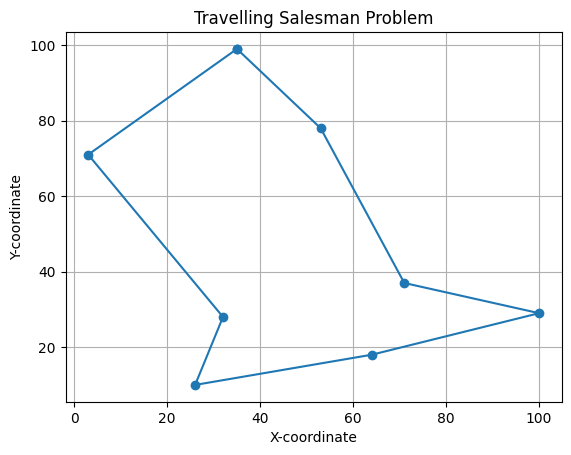


optimal distance =  292.3545728981788
optimal path =  [1, 2, 5, 3, 7, 0, 6, 4]


In [52]:
import numpy as np
import random
import matplotlib.pyplot as pl0t
routesPopulationSize = 500
routesPopulationArr = []
# citiesCount = 131
citiesCount = 8
cityArr = []
DistanceInfoMatrix = []
DistancesofRoutePopulation = []
generations = 20
selectPercent = 10
Mutation_nSwaps = 3
optimalDistance = 0
optimalRoute = []

print(" ** Hyperparameters Used ** ")
print(f"population size: ", routesPopulationSize)
print("cities : ", citiesCount)
print("generations: ", generations)
print("Select Percent: ", selectPercent)
print("Mutation Swaps: ", Mutation_nSwaps)


# 1. Define Citie
def InitialiseCities():
    global cityArr
    cityArr = []
    for i in range(citiesCount):
        x = random.randint(0, 100)
        y = random.randint(0, 100)
        cityArr.append([x, y])
    print("Cities = ", cityArr, "\n")
    return cityArr

# 2. Obtain DistanceInfoMatrix
def getEuclidean(location1, location2):
    euclDistance = np.sqrt(np.square(location2[0] - location1[0]) + np.square(location2[1] - location1[1]))
    return euclDistance

def InitialiseDistanceInfoMatrix():
    global DistanceInfoMatrix
    DistanceInfoMatrix = []
    for i in range(citiesCount):
        element = [0] * citiesCount
        DistanceInfoMatrix.append(element)

    for rowNum in range(citiesCount):
        for colNum in range(citiesCount):
            if rowNum != colNum:
                DistanceInfoMatrix[rowNum][colNum] = getEuclidean(cityArr[rowNum], cityArr[colNum])

# 3. Generate Routes
def getRoutes():
    global routesPopulationArr
    routesPopulationArr = []
    for i in range(routesPopulationSize):
        rout = list(range(citiesCount))
        random.shuffle(rout)
        routesPopulationArr.append(rout)

# 4. Fitness Function
def calcPathDist_FitnessFunction():
    global DistancesofRoutePopulation
    DistancesofRoutePopulation = []
    for routeList in routesPopulationArr:
        DistanceofRoute = 0
        for citynum in range(len(routeList)):
            city1 = routeList[citynum]
            city2 = routeList[(citynum+1) % citiesCount]
            DistanceofRoute += DistanceInfoMatrix[city1][city2]
        DistancesofRoutePopulation.append(float(DistanceofRoute))

# #### GENETIC ALGM #####
def performGeneticAlgorithmSteps():
    global optimalDistance, optimalRoute

    for generation in range(generations):
        # Selection
        ParentsofGen = performPercentParentSelection()

        # Crossover
        child = performCrossover(ParentsofGen)

        # Update population with parents + children
        routesPopulationArr.clear()
        routesPopulationArr.extend(ParentsofGen)
        routesPopulationArr.extend(child)

        # Mutation
        performMutation()

        # Recalculate fitness
        calcPathDist_FitnessFunction()

        # Print progress
        # if generation % 10 == 0:
        current_best = min(DistancesofRoutePopulation)
        print(f"Generation {generation}:  Best Distance Obtained = {current_best:.2f}")

    # Final results
    optimalDistance = min(DistancesofRoutePopulation)
    optimalRoute = routesPopulationArr[DistancesofRoutePopulation.index(optimalDistance)]


def performPercentParentSelection():
    Parent_Num = int(routesPopulationSize * selectPercent / 100)

    # Pair routes with distances and sort by distance
    route_distance_pairs = list(zip(routesPopulationArr, DistancesofRoutePopulation))
    sorted_pairs = sorted(route_distance_pairs, key=lambda x: x[1])

    # Select top routes as parents
    ParentList = [route for route, distance in sorted_pairs[:Parent_Num]]
    return ParentList

def performCrossover(ParentsofGen):
    childNumReqd = routesPopulationSize - len(ParentsofGen)
    totalChildProduced = []

    for i in range(childNumReqd):
        GenParent1, GenParent2 = random.sample(ParentsofGen, 2)
        size = len(GenParent1)
        indx1 = random.randint(0, size-1)
        indx2 = random.randint(indx1, size-1)

        genChild = [None] * size

        # Copy segment from parent1
        for pos in range(indx1, indx2 + 1):
            genChild[pos] = GenParent1[pos]

        # Fill remaining from parent2
        parent2Index = 0
        for pos in range(size):
            if genChild[pos] is None:
                while GenParent2[parent2Index] in genChild:
                    parent2Index = (parent2Index + 1) % size
                genChild[pos] = GenParent2[parent2Index]
                parent2Index = (parent2Index + 1) % size

        totalChildProduced.append(genChild)

    return totalChildProduced

# Mutation function
def performMutation():
    mutation_rate = 0.6

    for idx in range(len(routesPopulationArr)):
        if random.random() < mutation_rate:
            for swap_count in range(Mutation_nSwaps):
                cityU = random.randint(0, citiesCount-1)
                cityV = random.randint(0, citiesCount-1)
                # Swap cities in the current route
                routesPopulationArr[idx][cityU], routesPopulationArr[idx][cityV] = routesPopulationArr[idx][cityV], routesPopulationArr[idx][cityU]




def visualise():
  if optimalRoute is None:
    print("No optimal route found.")
  else:
    tourPoints = [cityArr[i] for i in optimalRoute] + [cityArr[optimalRoute[0]]]
    xcoord, ycoord = zip(*tourPoints)
    pl0t.plot(xcoord, ycoord, 'o-')
    pl0t.xlabel('X-coordinate')
    pl0t.ylabel('Y-coordinate')
    pl0t.title('Travelling Salesman Problem')
    pl0t.grid(True)
    pl0t.show()


cityArr = InitialiseCities()
InitialiseDistanceInfoMatrix()
getRoutes()
calcPathDist_FitnessFunction()
performGeneticAlgorithmSteps()
visualise()



print("\noptimal distance = ", optimalDistance)
print("optimal path = ", optimalRoute)

EA for BIGGER N

 ** Hyperparameters Used ** 
population size:  600
generations:  2000
Select Percent:  30
Mutation Swaps:  6
Generation 0:  Best Distance Obtained = 4061.20
Generation 1:  Best Distance Obtained = 3913.95
Generation 2:  Best Distance Obtained = 3886.62
Generation 3:  Best Distance Obtained = 3757.75
Generation 4:  Best Distance Obtained = 3626.20
Generation 5:  Best Distance Obtained = 3626.20
Generation 6:  Best Distance Obtained = 3516.38
Generation 7:  Best Distance Obtained = 3384.11
Generation 8:  Best Distance Obtained = 3384.11
Generation 9:  Best Distance Obtained = 3462.30
Generation 10:  Best Distance Obtained = 3379.76
Generation 11:  Best Distance Obtained = 3379.76
Generation 12:  Best Distance Obtained = 3245.84
Generation 13:  Best Distance Obtained = 3245.84
Generation 14:  Best Distance Obtained = 3293.14
Generation 15:  Best Distance Obtained = 3293.14
Generation 16:  Best Distance Obtained = 3293.14
Generation 17:  Best Distance Obtained = 3141.52
Generation 18:  Bes

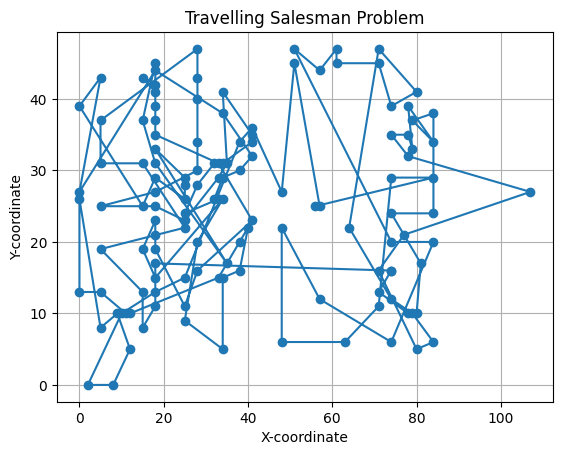


optimal distance =  1301.316086209665
optimal path =  [105, 100, 113, 120, 123, 107, 125, 128, 119, 127, 116, 118, 115, 109, 114, 130, 112, 101, 122, 129, 117, 104, 98, 103, 121, 110, 102, 95, 96, 94, 90, 106, 124, 111, 92, 86, 88, 97, 99, 108, 126, 91, 93, 89, 87, 85, 79, 45, 26, 14, 4, 12, 17, 13, 11, 1, 0, 5, 15, 16, 63, 77, 80, 76, 67, 73, 52, 54, 68, 27, 19, 31, 30, 29, 44, 53, 81, 66, 37, 38, 39, 40, 23, 41, 43, 22, 35, 74, 36, 51, 50, 49, 34, 20, 3, 10, 2, 42, 71, 82, 78, 69, 61, 64, 48, 55, 62, 70, 83, 84, 72, 75, 65, 47, 32, 7, 33, 56, 57, 58, 59, 60, 9, 8, 21, 46, 6, 18, 24, 25, 28]


In [63]:
import numpy as np
import random
import matplotlib.pyplot as pl0t
routesPopulationSize = 600
routesPopulationArr = []
cityArr = []
DistanceInfoMatrix = []
DistancesofRoutePopulation = []
generations = 2000
selectPercent = 30
Mutation_nSwaps = 6
optimalDistance = 0
optimalRoute = []

print(" ** Hyperparameters Used ** ")
print(f"population size: ", routesPopulationSize)
# print("cities : ", citiesCount)
print("generations: ", generations)
print("Select Percent: ", selectPercent)
print("Mutation Swaps: ", Mutation_nSwaps)

ipfile = "/content/xqf131.tsp"
# ipfile = "/content/xqg237.tsp"
# inputParts = []

# def input
# I dont need other generations. It repeats after few generatios
def input(ipfile):
  with open(ipfile, 'r') as file:
    global citiesCount
    linesRed = file.readlines()
    found = False
    for eachLine in linesRed:
      if eachLine.__contains__("EOF"):
        break
      if eachLine is not None and eachLine.__contains__("DIMENSION") :
        citiesCount = int(eachLine.strip().split(':')[1])
        # print("CitiesCount = ", citiesCount)
      if eachLine is not None and eachLine.__contains__("NODE_COORD_SECTION") :
        found = True
        continue

      if found == True and eachLine is not None:
        # inputParts.append(eachLine.split(' ').strip())
        # cityNo, xcor, ycor = eachLine.split(' ').strip()
        inputParts = eachLine.strip().split()
        if len(inputParts) == 3:
          cityNo = inputParts[0]
          cityArr.append([float(inputParts[1]), float(inputParts[2])])



# 2. Obtain DistanceInfoMatrix using euclidean distance
def getEuclidean(location1, location2):
    euclDistance = np.sqrt(np.square(location2[0] - location1[0]) + np.square(location2[1] - location1[1]))
    return euclDistance

def InitialiseDistanceInfoMatrix():
    global DistanceInfoMatrix

    DistanceInfoMatrix = []
    for i in range(citiesCount):
        element = [0] * citiesCount
        DistanceInfoMatrix.append(element)

    for rowNum in range(citiesCount):
        for colNum in range(citiesCount):
            if rowNum != colNum:
                DistanceInfoMatrix[rowNum][colNum] = getEuclidean(cityArr[rowNum], cityArr[colNum])

# 3. Generate Routes
def getRoutes():
    global routesPopulationArr
    routesPopulationArr = []
    for i in range(routesPopulationSize):
        # print("citiesCount in getReoutes = ", citiesCount)
        rout = list(range(citiesCount))
        random.shuffle(rout)
        routesPopulationArr.append(rout)

# 4. Fitness Function
def calcPathDist_FitnessFunction():
    global DistancesofRoutePopulation
    DistancesofRoutePopulation = []
    for routeList in routesPopulationArr:
        DistanceofRoute = 0
        for citynum in range(len(routeList)):
            city1 = routeList[citynum]
            city2 = routeList[(citynum+1) % citiesCount]
            DistanceofRoute += DistanceInfoMatrix[city1][city2]
        DistancesofRoutePopulation.append(float(DistanceofRoute))

# #### GENETIC ALGM #####
def performGeneticAlgorithmSteps():
    global optimalDistance, optimalRoute

    for generation in range(generations):
        # Selection
        ParentsofGen = performPercentParentSelection()

        # Crossover
        child = performCrossover(ParentsofGen)

        # Update population with parents + children
        routesPopulationArr.clear()
        routesPopulationArr.extend(ParentsofGen)
        routesPopulationArr.extend(child)

        # Mutation
        performMutation()

        # Recalculate fitness
        calcPathDist_FitnessFunction()

        # Print progress
        # if generation % 10 == 0:
        current_best = min(DistancesofRoutePopulation)
        print(f"Generation {generation}:  Best Distance Obtained = {current_best:.2f}")

    # Final results
    optimalDistance = min(DistancesofRoutePopulation)
    optimalRoute = routesPopulationArr[DistancesofRoutePopulation.index(optimalDistance)]


def performPercentParentSelection():
    Parent_Num = int(routesPopulationSize * selectPercent / 100)

    # Pair routes with distances and sort by distance
    route_distance_pairs = list(zip(routesPopulationArr, DistancesofRoutePopulation))
    sorted_pairs = sorted(route_distance_pairs, key=lambda x: x[1])

    # Select top routes as parents
    ParentList = [route for route, distance in sorted_pairs[:Parent_Num]]
    return ParentList

def performCrossover(ParentsofGen):
    childNumReqd = routesPopulationSize - len(ParentsofGen)
    totalChildProduced = []

    for i in range(childNumReqd):
        GenParent1, GenParent2 = random.sample(ParentsofGen, 2)
        size = len(GenParent1)
        indx1 = random.randint(0, size-1)
        indx2 = random.randint(indx1, size-1)

        genChild = [None] * size

        # Copy segment from parent1
        for pos in range(indx1, indx2 + 1):
            genChild[pos] = GenParent1[pos]

        # Fill remaining from parent2
        parent2Index = 0
        for pos in range(size):
            if genChild[pos] is None:
                while GenParent2[parent2Index] in genChild:
                    parent2Index = (parent2Index + 1) % size
                genChild[pos] = GenParent2[parent2Index]
                parent2Index = (parent2Index + 1) % size

        totalChildProduced.append(genChild)

    return totalChildProduced

# Mutation function
def performMutation():
    mutation_rate = 0.6

    for idx in range(len(routesPopulationArr)):
        if random.random() < mutation_rate:
            for swap_count in range(Mutation_nSwaps):
                cityU = random.randint(0, citiesCount-1)
                cityV = random.randint(0, citiesCount-1)
                # Swap cities in the current route
                routesPopulationArr[idx][cityU], routesPopulationArr[idx][cityV] = routesPopulationArr[idx][cityV], routesPopulationArr[idx][cityU]




def visualise():
  if optimalRoute is None:
    print("No optimal route found.")
  else:
    if optimalRoute is not None:
      tourPoints = [cityArr[i] for i in optimalRoute] + [cityArr[optimalRoute[0]]]
      xcoord, ycoord = zip(*tourPoints)
      pl0t.plot(xcoord, ycoord, 'o-')
      pl0t.xlabel('X-coordinate')
      pl0t.ylabel('Y-coordinate')
      pl0t.title('Travelling Salesman Problem')
      pl0t.grid(True)
      pl0t.show()


input(ipfile)
InitialiseDistanceInfoMatrix()
getRoutes()
calcPathDist_FitnessFunction()
performGeneticAlgorithmSteps()
visualise()



print("\noptimal distance = ", optimalDistance)
print("optimal path = ", optimalRoute)